# Summative Lab – Analytics Firm Clients: Customer Reviews Analysis

This notebook is a **starter notebook** for the three parts of the lab:

1. NLP  
2. Time Series  
3. Neural Networks  

Use the comments and TODO prompts to guide your work. The notebook is intentionally incomplete so you can implement the analysis yourself.


## Part 1: NLP

In this section, you will clean and preprocess review text, explore frequent words and bigrams, and visualize key language patterns in the dataset.


Part 1: NLP Starter Code

Import the libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing
import re
import string

# NLTK
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer,PorterStemmer
from nltk.tokenize import word_tokenize, sent_tokenize

# Counting
from collections import Counter
from nltk.util import ngrams

Download NLTK resources

In [2]:
nltk.download('punkt')
nltk.download('punkt_tab')      # needed for newer NLTK versions
nltk.download('stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("averaged_perceptron_tagger")
nltk.download("averaged_perceptron_tagger")

[nltk_data] Error loading punkt: <urlopen error pathsec.urlopen: no
[nltk_data]     validated address for host
[nltk_data]     'raw.githubusercontent.com'; refusing to connect by
[nltk_data]     unvalidated hostname>
[nltk_data] Error loading punkt_tab: <urlopen error pathsec.urlopen:
[nltk_data]     no validated address for host
[nltk_data]     'raw.githubusercontent.com'; refusing to connect by
[nltk_data]     unvalidated hostname>
[nltk_data] Error loading stopwords: <urlopen error pathsec.urlopen:
[nltk_data]     no validated address for host
[nltk_data]     'raw.githubusercontent.com'; refusing to connect by
[nltk_data]     unvalidated hostname>
[nltk_data] Error loading wordnet: <urlopen error pathsec.urlopen: no
[nltk_data]     validated address for host
[nltk_data]     'raw.githubusercontent.com'; refusing to connect by
[nltk_data]     unvalidated hostname>
[nltk_data] Error loading omw-1.4: <urlopen error pathsec.urlopen: no
[nltk_data]     validated address for host
[nltk_dat

False

In [3]:
# For dataset loading
from sklearn.datasets import fetch_20newsgroups


# Set random seed for reproducibility
np.random.seed(42)


Load the dataset

In [4]:
df = pd.read_csv("amazon_reviews_lab.csv")
df.head()

,product_id,rating,review_text,review_summary,review_time_raw,unix_review_time,timestamp,sentiment_label,review_length_words
0,6301977173,2,This film is definitely not for anyone who is ...,The best of Mark Twain's work - left out!,"05 12, 2000",9.580896e+08,2000-05-12,negative,302
1,6301977173,5,This movie was playing at Radio City Music Hal...,The best Tom Sawyer i ever saw.,"08 26, 2002",1.030320e+09,2002-08-26,positive,168
2,6301977173,1,I would love to buy this movie as I have been ...,Why no Widescreen?,"08 6, 2005",1.123286e+09,2005-08-06,negative,60
3,6301977173,1,The advertisment for this DVD on Amazon was in...,False advertising on this DVD,"09 11, 2005",1.126397e+09,2005-09-11,negative,104
4,9575871979,5,I bought some of these to try with a light usi...,Work GREAT!!,"10 15, 2007",1.192406e+09,2007-10-15,positive,60


In [154]:
df

,product_id,rating,review_text,review_summary,review_time_raw,unix_review_time,timestamp,sentiment_label,review_length_words
0,6301977173,2,This film is definitely not for anyone who is ...,The best of Mark Twain's work - left out!,"05 12, 2000",9.580896e+08,2000-05-12,negative,302
1,6301977173,5,This movie was playing at Radio City Music Hal...,The best Tom Sawyer i ever saw.,"08 26, 2002",1.030320e+09,2002-08-26,positive,168
2,6301977173,1,I would love to buy this movie as I have been ...,Why no Widescreen?,"08 6, 2005",1.123286e+09,2005-08-06,negative,60
3,6301977173,1,The advertisment for this DVD on Amazon was in...,False advertising on this DVD,"09 11, 2005",1.126397e+09,2005-09-11,negative,104
4,9575871979,5,I bought some of these to try with a light usi...,Work GREAT!!,"10 15, 2007",1.192406e+09,2007-10-15,positive,60
...,...,...,...,...,...,...,...,...,...
992,0972683275,5,"This is a great buy, compared to a $60 or more...",Excelant mount for Tv. Would buy more if I nee...,"07 12, 2014",1.405123e+09,2014-07-12,positive,14
993,9575871979,5,"I use CR123A batteries like candy, I didn't kn...",Great value and saves a ton after two uses.,"07 13, 2014",1.405210e+09,2014-07-13,positive,60
994,1400699169,5,A year after Barnes and Noble dropped the pric...,Great Value! Don't wait too long... they are n...,"07 14, 2014",1.405296e+09,2014-07-14,positive,465
995,1400532655,1,Not worth saving a few bucks. Go with an iPad.,Not user friendly. Very time consuming to find...,"07 14, 2014",1.405296e+09,2014-07-14,negative,10


Explore the dataset

In [5]:
print(df.shape)


(997, 9)


In [6]:

print(df["rating"].value_counts().sort_index())


rating
1     87
2     48
3     94
4    188
5    580
Name: count, dtype: int64


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 997 entries, 0 to 996
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           997 non-null    object 
 1   rating               997 non-null    int64  
 2   review_text          997 non-null    object 
 3   review_summary       997 non-null    object 
 4   review_time_raw      997 non-null    object 
 5   unix_review_time     997 non-null    float64
 6   timestamp            997 non-null    object 
 7   sentiment_label      997 non-null    object 
 8   review_length_words  997 non-null    int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 70.2+ KB


In [8]:
df.isnull().sum()

product_id             0
rating                 0
review_text            0
review_summary         0
review_time_raw        0
unix_review_time       0
timestamp              0
sentiment_label        0
review_length_words    0
dtype: int64

Convert timestamp to datetime

Since the timestamp is an object we need to convert it to datatime 

In [9]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [ ]:
df["unix_review_time"] = pd.to_datetime(df["unix_review_time"])

In [11]:
df["timestamp"].dtype

dtype('<M8[ns]')

In [12]:
df[["rating", "review_text"]].head()

,rating,review_text
0,2,This film is definitely not for anyone who is ...
1,5,This movie was playing at Radio City Music Hal...
2,1,I would love to buy this movie as I have been ...
3,1,The advertisment for this DVD on Amazon was in...
4,5,I bought some of these to try with a light usi...


Create preprocessing tools

stopwords and Lemmatizer

In [13]:
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

Create a function called preprocess_text(text) that, respectively:
 1. converts text to lowercase
 2. removes URLs
 3. removes punctuation
 4. tokenizes the text
 5. keeps alphabetic tokens only
 6. removes stopwords
 7. lemmatizes the remaining tokens
 8. returns the cleaned tokens

In [14]:
def preprocess_text(text):
    text = str(text).lower()
    
    text = re.sub(r'http\S+|www\. \S+', '',text)
    
    text = text.translate(str.maketrans('', '',string.punctuation))
    
    tokens = word_tokenize(text)
    
    tokens = [token for token in tokens if token.isalpha()]
    
    tokens = [token for token in tokens if token not in stop_words]
    
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    
    return tokens 



In [15]:
review1 = df["review_text"].iloc[0]

print("Orginal\n", review1[:500])

print("----------------------------")

print("Processsed\n", preprocess_text(review1)[:30])


Orginal
 This film is definitely not for anyone who is especially fond of the independent, delightfully manipulative and clever boy who was the brain child of Samuel Clemens's classic.As one example, the book has great fun with the scenes involving Aunt Polly, a simple minded soul who thinks herself quite clever, and the genuinely shrewd Tom, who plays on catering to Polly's illusions about her own wit. This is a far cry from beautiful, intelligent Celeste Holm's portrayal of Polly - and the family's pov
----------------------------
Processsed
 ['film', 'definitely', 'anyone', 'especially', 'fond', 'independent', 'delightfully', 'manipulative', 'clever', 'boy', 'brain', 'child', 'samuel', 'clemens', 'classicas', 'one', 'example', 'book', 'great', 'fun', 'scene', 'involving', 'aunt', 'polly', 'simple', 'minded', 'soul', 'think', 'quite', 'clever']


Apply your preprocessing function to the review text column and and store the output in a new column such as 'processed_tokens

In [16]:
df["processed_tokens"] =  df["review_text"].apply(preprocess_text)
df[["review_text", "processed_tokens"]].head()

,review_text,processed_tokens
0,This film is definitely not for anyone who is ...,"[film, definitely, anyone, especially, fond, i..."
1,This movie was playing at Radio City Music Hal...,"[movie, playing, radio, city, music, hall, bac..."
2,I would love to buy this movie as I have been ...,"[would, love, buy, movie, hannibal, missouri, ..."
3,The advertisment for this DVD on Amazon was in...,"[advertisment, dvd, amazon, incorrect, ad, sta..."
4,I bought some of these to try with a light usi...,"[bought, try, light, using, work, advertised, ..."


Combine all tokens into one list so you can compute word frequencies.


In [17]:
combined_tokens = []

for tokens in df["processed_tokens"]:
    combined_tokens.extend(tokens)
    
print("Total tokens is:", len(combined_tokens))   
print("Unique tokens is:", len(set(combined_tokens)))  
    
# token for tokens in df["processed_token"] for token in tokens]

Total tokens is: 72140
Unique tokens is: 8587


Identify the most common words using Counter


In [18]:
common_words = Counter(combined_tokens)
the_top_words = common_words.most_common(25)

the_top_words

[('nook', 1509),
 ('book', 913),
 ('one', 569),
 ('kindle', 561),
 ('screen', 496),
 ('like', 459),
 ('read', 454),
 ('work', 446),
 ('get', 424),
 ('great', 422),
 ('use', 420),
 ('tablet', 419),
 ('tv', 416),
 ('device', 381),
 ('would', 378),
 ('good', 330),
 ('bn', 321),
 ('time', 318),
 ('also', 317),
 ('well', 305),
 ('mount', 303),
 ('reading', 282),
 ('card', 280),
 ('price', 277),
 ('bought', 276)]

In [19]:
top_words= [words[0] for words in the_top_words]

top_words


['nook',
 'book',
 'one',
 'kindle',
 'screen',
 'like',
 'read',
 'work',
 'get',
 'great',
 'use',
 'tablet',
 'tv',
 'device',
 'would',
 'good',
 'bn',
 'time',
 'also',
 'well',
 'mount',
 'reading',
 'card',
 'price',
 'bought']

visualization of the most common words.

/tmp/ipykernel_8839/3283751628.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='viridis')


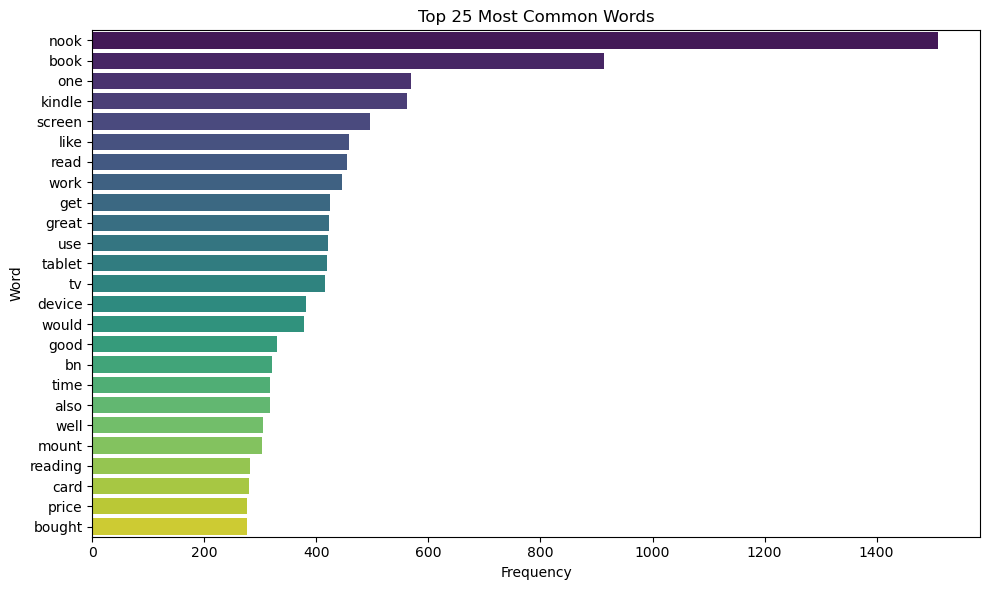

In [20]:
words, counts = zip(*the_top_words)

plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(words), palette='viridis')
plt.title('Top 25 Most Common Words')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.show()

Generate bigrams from the token list and identify the most common bigrams

In [21]:
bigrams = list(ngrams(combined_tokens, 2))
bigrams_counts = Counter(bigrams)
top_bigrams = bigrams_counts.most_common(25)

top_bigrams

[(('barnes', 'noble'), 152),
 (('nook', 'color'), 127),
 (('battery', 'life'), 87),
 (('touch', 'screen'), 81),
 (('sd', 'card'), 80),
 (('nook', 'hd'), 74),
 (('work', 'great'), 63),
 (('nook', 'tablet'), 63),
 (('work', 'well'), 57),
 (('read', 'book'), 55),
 (('kindle', 'fire'), 55),
 (('wall', 'mount'), 51),
 (('simple', 'touch'), 44),
 (('android', 'tablet'), 39),
 (('customer', 'service'), 38),
 (('nook', 'simple'), 37),
 (('bn', 'store'), 35),
 (('easy', 'install'), 34),
 (('original', 'nook'), 34),
 (('ebook', 'reader'), 33),
 (('work', 'fine'), 32),
 (('google', 'play'), 32),
 (('page', 'turn'), 31),
 (('credit', 'card'), 31),
 (('free', 'book'), 31)]

In [22]:
top_bigrams_str = [(' '.join(bg), c) for bg, c in top_bigrams]
top_bigrams_str

[('barnes noble', 152),
 ('nook color', 127),
 ('battery life', 87),
 ('touch screen', 81),
 ('sd card', 80),
 ('nook hd', 74),
 ('work great', 63),
 ('nook tablet', 63),
 ('work well', 57),
 ('read book', 55),
 ('kindle fire', 55),
 ('wall mount', 51),
 ('simple touch', 44),
 ('android tablet', 39),
 ('customer service', 38),
 ('nook simple', 37),
 ('bn store', 35),
 ('easy install', 34),
 ('original nook', 34),
 ('ebook reader', 33),
 ('work fine', 32),
 ('google play', 32),
 ('page turn', 31),
 ('credit card', 31),
 ('free book', 31)]

visualization of the most common words.



/tmp/ipykernel_8839/1877081918.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(bg_counts), y=list(bg_labels), palette='magma')


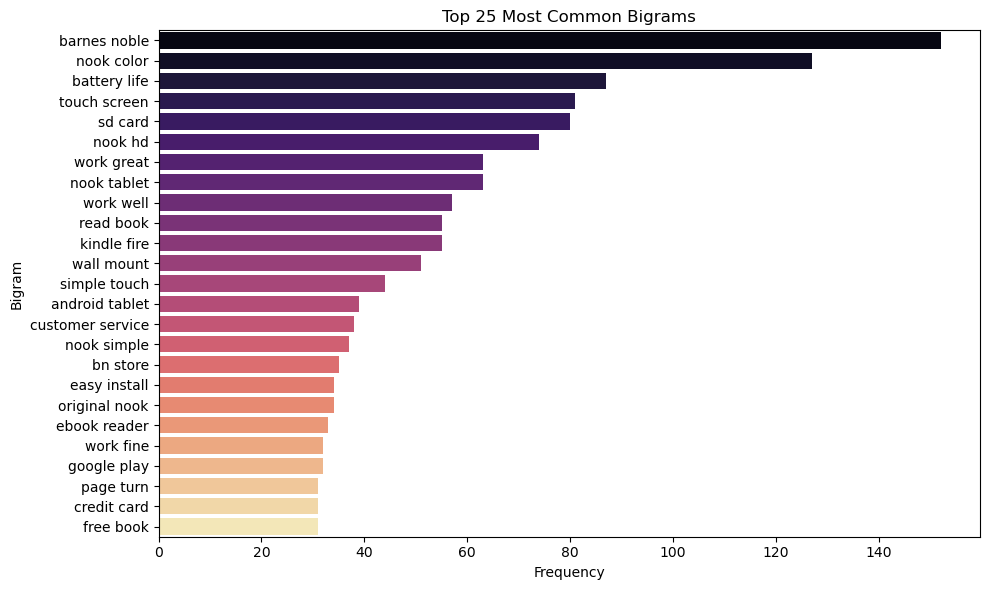

In [23]:
bg_labels, bg_counts = zip(*top_bigrams_str)

plt.figure(figsize=(10, 6))
sns.barplot(x=list(bg_counts), y=list(bg_labels), palette='magma')
plt.title('Top 25 Most Common Bigrams')
plt.xlabel('Frequency')
plt.ylabel('Bigram')
plt.tight_layout()
plt.show()

Reflection prompt:

The review text was preprocessed by lowercasing, removing URLs and punctuation, tokenizing, dropping stopwords, and lemmatizing. Word and bigram frequencies were then computed across all reviews and visualized.


Top words: nook, kindle, book, read, screen, battery, amazon, barnes, noble

Top bigrams: barnes noble, nook color, kindle fire, battery life, page turn, customer service

The review was mostly from ebooks readers and accesories buyers.They were about product features

Positive reviews were love, great, easy, read; negative reviews cluster around problem, return, freeze, battery, support.

## Part 2: Time Series

In this section, you will analyze review activity over time by converting timestamps, resampling the data, and visualizing trends in review volume and ratings.


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 997 entries, 0 to 996
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   product_id           997 non-null    object        
 1   rating               997 non-null    int64         
 2   review_text          997 non-null    object        
 3   review_summary       997 non-null    object        
 4   review_time_raw      997 non-null    object        
 5   unix_review_time     997 non-null    datetime64[ns]
 6   timestamp            997 non-null    datetime64[ns]
 7   sentiment_label      997 non-null    object        
 8   review_length_words  997 non-null    int64         
 9   processed_tokens     997 non-null    object        
dtypes: datetime64[ns](2), int64(2), object(6)
memory usage: 78.0+ KB


Inspect the date range in the dataset.

In [25]:
# earliest timestamp
# latest timestamp

print ("Earliest timestamp:", df["timestamp"].min())
print ("Latest timestamp: ", df["timestamp"].max())
print ("Span (Days):", (df["timestamp"].max() - df["timestamp"].min()).days)


Earliest timestamp: 2000-05-12 00:00:00
Latest timestamp:  2014-07-17 00:00:00
Span (Days): 5179


Resample the data by month to calculate:

1. monthly review count

2. monthly average rating

In [26]:
df_ts = df.set_index("timestamp").sort_index()

Calculate monthly review count

In [27]:
monthly_review_count = df_ts["rating"].resample("MS").count()
monthly_avg_rating =  df_ts["rating"].resample("MS").mean()

print(monthly_review_count.head())
print(monthly_review_count.tail())
print(monthly_avg_rating.describe())

timestamp
2000-05-01    1
2000-06-01    0
2000-07-01    0
2000-08-01    0
2000-09-01    0
Freq: MS, Name: rating, dtype: int64
timestamp
2014-03-01    30
2014-04-01    22
2014-05-01    12
2014-06-01    15
2014-07-01    13
Freq: MS, Name: rating, dtype: int64
count    68.000000
mean      3.973860
std       0.721530
min       1.000000
25%       3.813636
50%       4.054348
75%       4.364286
max       5.000000
Name: rating, dtype: float64


Plot monthly review volume over time.

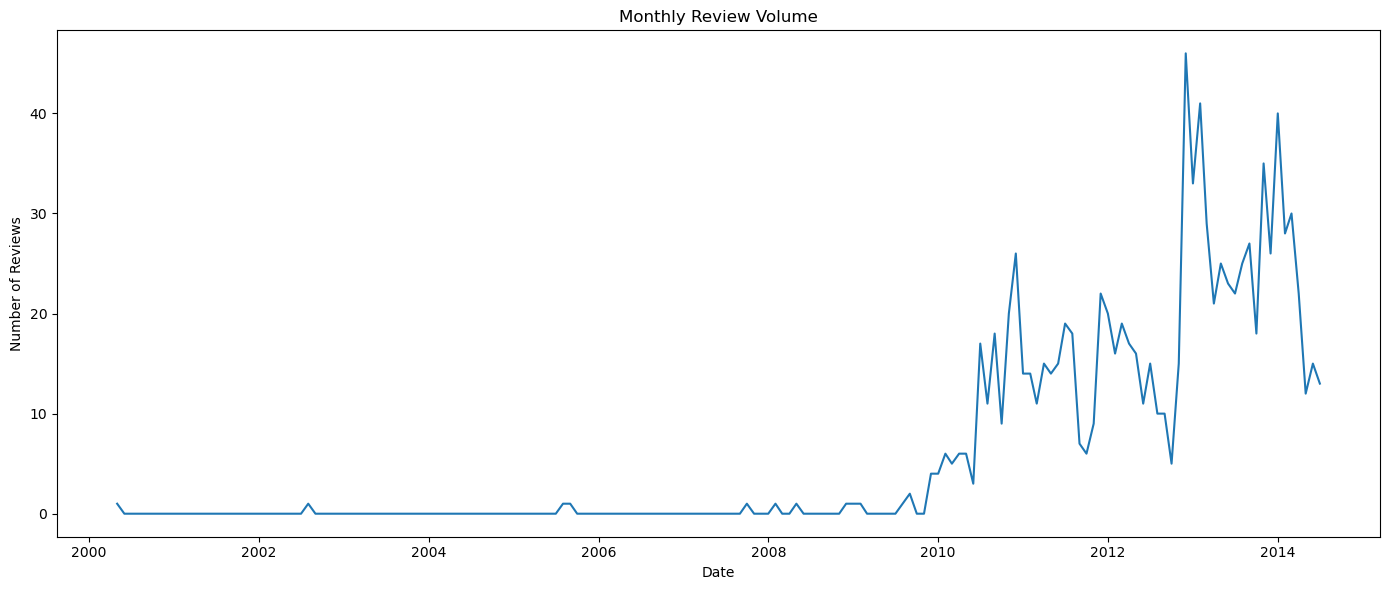

In [28]:
plt.figure(figsize=(14, 6))

plt.plot(monthly_review_count)

plt.title('Monthly Review Volume')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')

plt.tight_layout()
plt.show()

Plot average monthly rating over time.

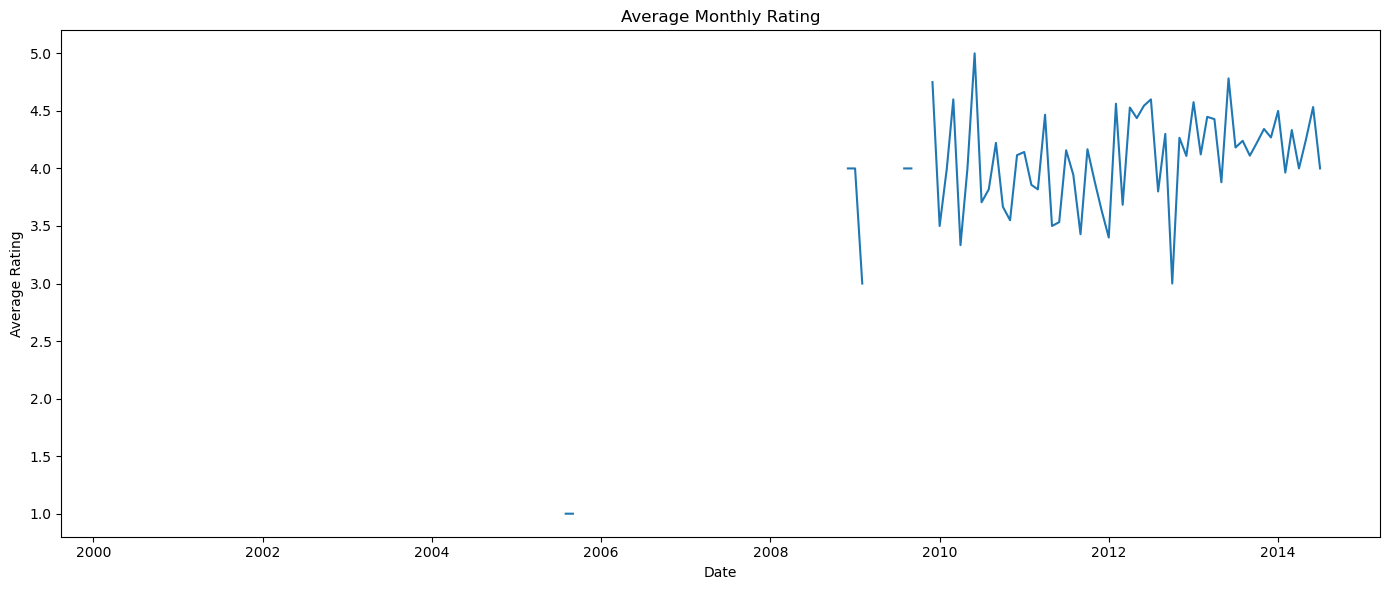

In [29]:
plt.figure(figsize=(14, 6))

plt.plot(monthly_avg_rating)

plt.title('Average Monthly Rating')
plt.xlabel('Date')
plt.ylabel('Average Rating')

plt.tight_layout()
plt.show()


Compute a rolling average for the monthly average rating.

In [30]:
rolling_avg_rating = monthly_avg_rating.rolling(window=3,min_periods=1).mean()
rolling_avg_rating

timestamp
2000-05-01    2.000000
2000-06-01    2.000000
2000-07-01    2.000000
2000-08-01         NaN
2000-09-01         NaN
                ...   
2014-03-01    4.265873
2014-04-01    4.099206
2014-05-01    4.194444
2014-06-01    4.261111
2014-07-01    4.261111
Freq: MS, Name: rating, Length: 171, dtype: float64

Plot both: The original monthly average rating and The rolling average on the same figure.


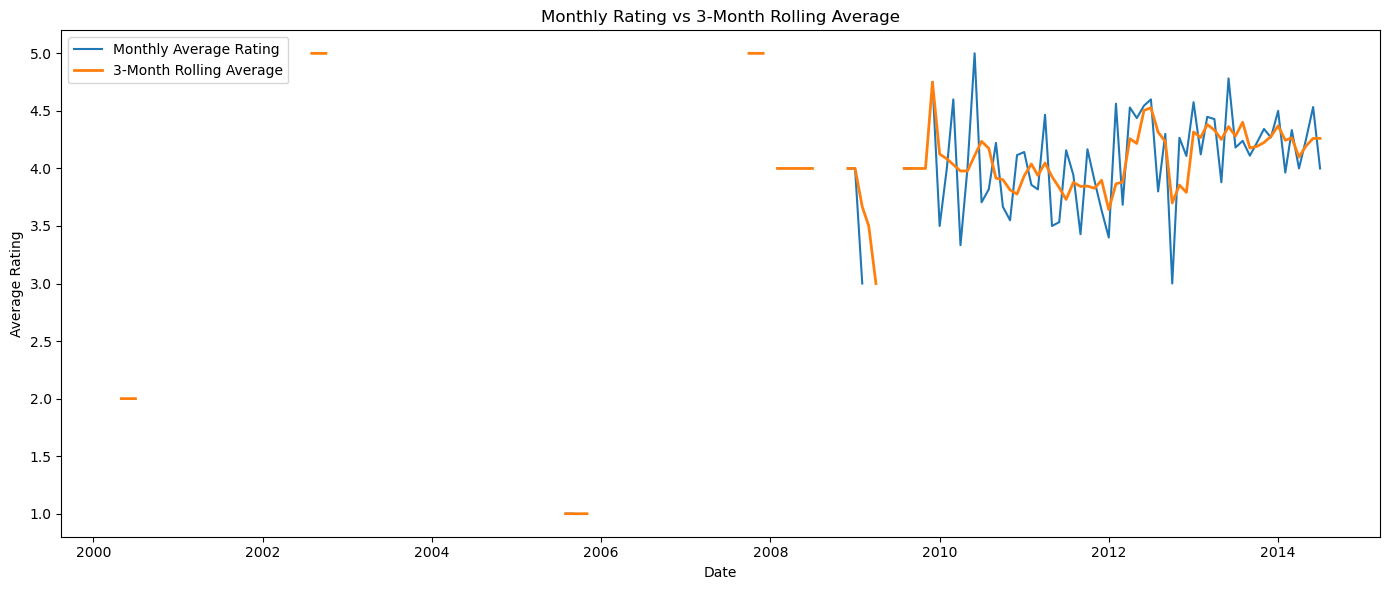

In [31]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_avg_rating,
    label='Monthly Average Rating'
)

plt.plot(
    rolling_avg_rating,
    label='3-Month Rolling Average',
    linewidth=2
)

plt.title('Monthly Rating vs 3-Month Rolling Average')
plt.xlabel('Date')
plt.ylabel('Average Rating')

plt.legend()

plt.tight_layout()
plt.show()

In [32]:
top_months = monthly_review_count.sort_values(ascending=False).head(10)
print(top_months)

top_rating_months = monthly_avg_rating.sort_values(ascending=False).head(10)
print(top_rating_months)

bottom_rating_months = monthly_avg_rating.sort_values().head(10)
print(bottom_rating_months)

timestamp
2012-12-01    46
2013-02-01    41
2014-01-01    40
2013-11-01    35
2013-01-01    33
2014-03-01    30
2013-03-01    29
2014-02-01    28
2013-09-01    27
2010-12-01    26
Name: rating, dtype: int64
timestamp
2002-08-01    5.000000
2007-10-01    5.000000
2010-06-01    5.000000
2013-06-01    4.782609
2009-12-01    4.750000
2012-07-01    4.600000
2010-03-01    4.600000
2013-01-01    4.575758
2012-02-01    4.562500
2012-06-01    4.545455
Name: rating, dtype: float64
timestamp
2005-09-01    1.000000
2005-08-01    1.000000
2000-05-01    2.000000
2009-02-01    3.000000
2012-10-01    3.000000
2010-04-01    3.333333
2012-01-01    3.400000
2011-09-01    3.428571
2011-05-01    3.500000
2010-01-01    3.500000
Name: rating, dtype: float64


Check Stationarity and Apply Transformations

In [161]:
from statsmodels.tsa.stattools import adfuller, kpss

# Our main time series
ts = monthly_avg_rating.dropna()

print("\nNumber of observations:", len(ts))
print("Missing values:", ts.isna().sum())


Number of observations: 68
Missing values: 0


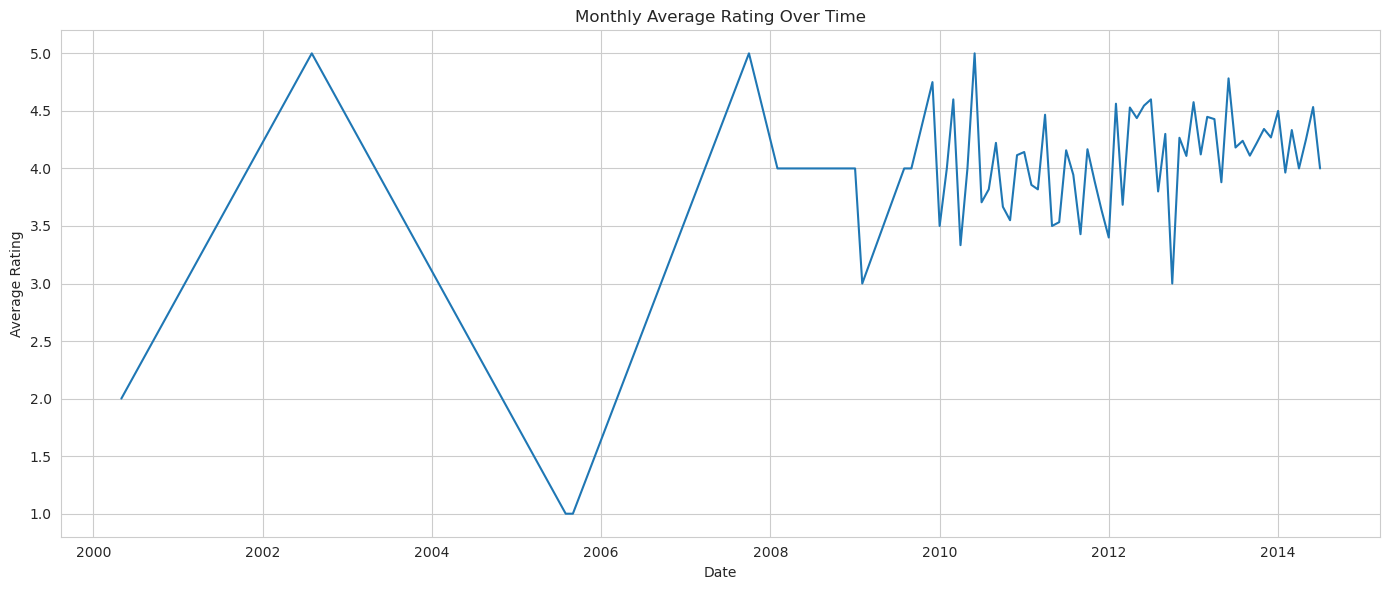

In [162]:

plt.figure(figsize=(14, 6))

plt.plot(ts)

plt.title("Monthly Average Rating Over Time")
plt.xlabel("Date")
plt.ylabel("Average Rating")

plt.tight_layout()
plt.show()



In [165]:
adf_result = adfuller(ts)

print("ADF Statistic:", adf_result[0])
print("ADF p-value:", adf_result[1])

if adf_result[1] < 0.05:
    print("Conclusion: The rating series is stationary.")
else:
    print("Conclusion: The rating series is NOT stationary.")

ADF Statistic: -1.4556884669077446
ADF p-value: 0.5553067746051638
Conclusion: The rating series is NOT stationary.


In [166]:

kpss_result = kpss(
    ts,
    regression="c",
    nlags="auto"
)

print("KPSS Statistic:", kpss_result[0])
print("KPSS p-value:", kpss_result[1])

if kpss_result[1] < 0.05:
    print("Conclusion: The rating series is NOT stationary.")
else:
    print("Conclusion: The rating series is stationary.")

KPSS Statistic: 0.8325566268595885
KPSS p-value: 0.01
Conclusion: The rating series is NOT stationary.


/tmp/ipykernel_8839/2338862296.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(


Apply first differencing

In [167]:
# First-order differencing
ts_diff = ts.diff().dropna()

print(ts_diff.head())

timestamp
2002-08-01    3.0
2005-08-01   -4.0
2005-09-01    0.0
2007-10-01    4.0
2008-02-01   -1.0
Name: rating, dtype: float64


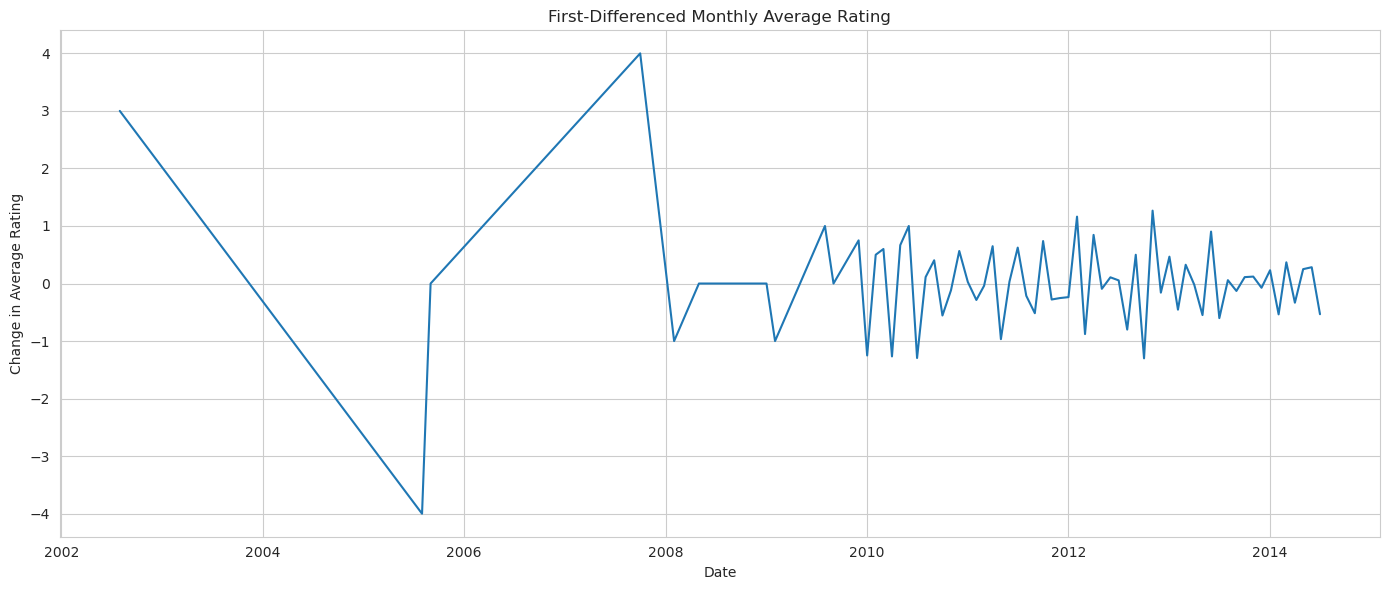

In [168]:
plt.figure(figsize=(14, 6))

plt.plot(ts_diff)

plt.title("First-Differenced Monthly Average Rating")
plt.xlabel("Date")
plt.ylabel("Change in Average Rating")

plt.tight_layout()
plt.show()

ADF test after first differencing

In [169]:
adf_diff = adfuller(ts_diff)

print("ADF Statistic after differencing:", adf_diff[0])
print("ADF p-value after differencing:", adf_diff[1])

if adf_diff[1] < 0.05:
    print("Conclusion: The differenced rating series is stationary.")
else:
    print("Conclusion: The differenced rating series is NOT stationary.")

ADF Statistic after differencing: -5.464464508721835
ADF p-value after differencing: 2.4766068541946624e-06
Conclusion: The differenced rating series is stationary.


Decompose and Diagnose Patterns

We will decompose the monthly customer ratings into trend, seasonal, and residual components to identify long-term movements, recurring yearly patterns, and what's left after removing trend and seasonality.

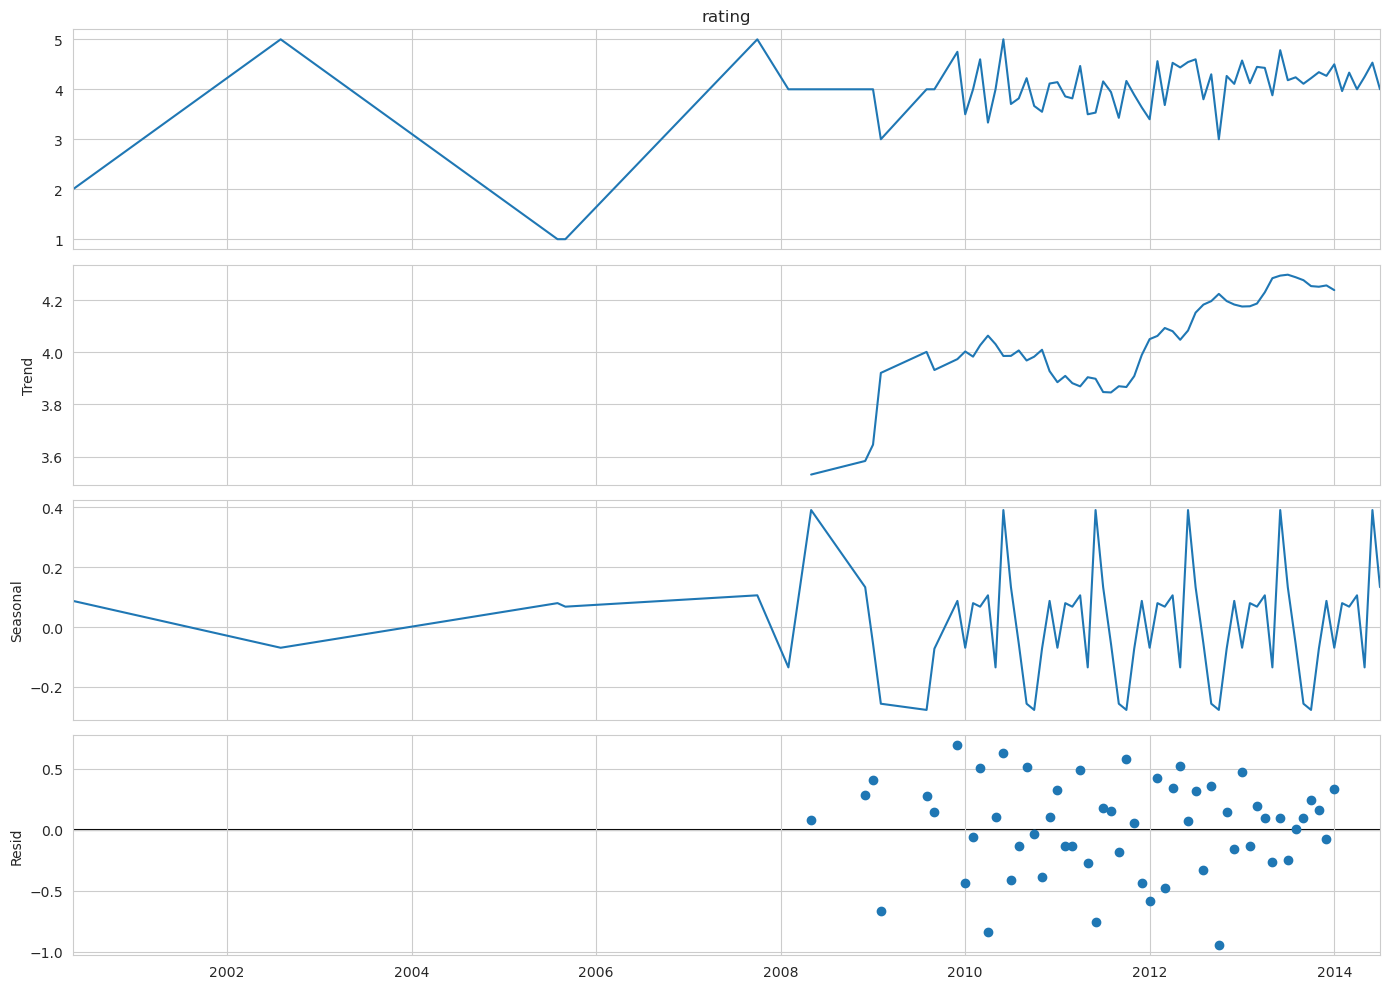

In [172]:
from statsmodels.tsa.seasonal import seasonal_decompose


rating_ts = monthly_avg_rating.dropna()

decomposition = seasonal_decompose(
    rating_ts,
    model="additive",
    period=12
)

fig = decomposition.plot()

fig.set_size_inches(14, 10)

plt.tight_layout()
plt.show()

Trend component - Average ratings show an overall increase over time, beginning around 2009. This suggests a long-term improvement in customer satisfaction.

Seasonal component - it exhibits a repeating 12-month pattern, indicating that ratings have a monthly seasonal rhythm.

Residual component - Residuals are centered roughly on 0.

Lets look at the autocorrelation by plotting ACF and PACF plots

<Figure size 1200x500 with 0 Axes>

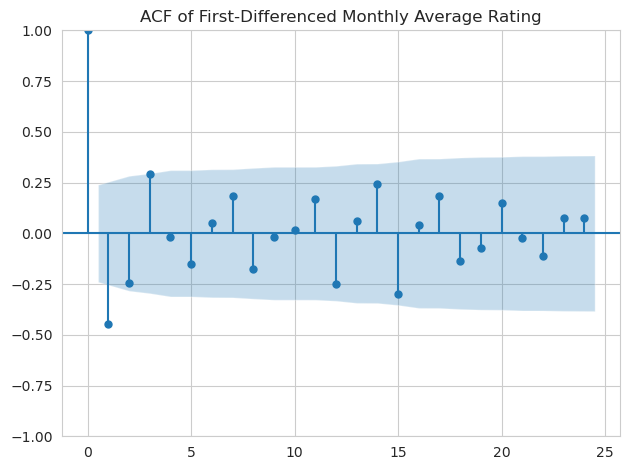

In [174]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12, 5))

plot_acf(
    ts_diff,
    lags=24
)

plt.title("ACF of First-Differenced Monthly Average Rating")

plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

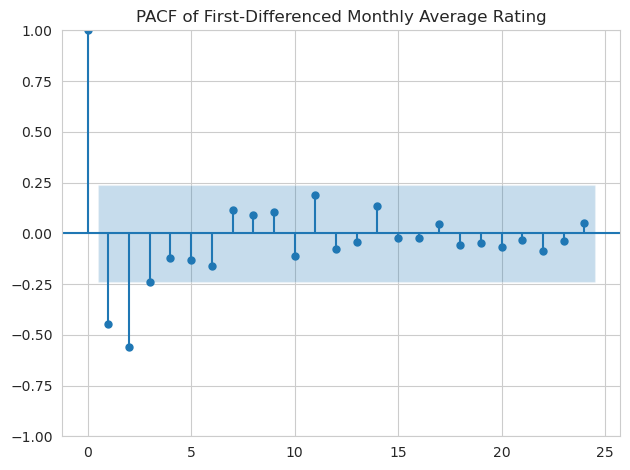

In [175]:
# PACF of differenced ratings
plt.figure(figsize=(12, 5))

plot_pacf(
    ts_diff,
    lags=24,
    method="ywm"
)

plt.title("PACF of First-Differenced Monthly Average Rating")

plt.tight_layout()
plt.show()

Compare ARIMA models

In [177]:
from statsmodels.tsa.arima.model import ARIMA

import pandas as pd
import numpy as np

models = [
    (1, 1, 0),
    (2, 1, 0),
    (3, 1, 0),
    (0, 1, 1),
    (1, 1, 1),
    (2, 1, 1),
    (3, 1, 1)
]

results = []

for order in models:

    model = ARIMA(ts, order=order)
    fitted_model = model.fit()

    results.append({
        "Model": f"ARIMA{order}",
        "AIC": fitted_model.aic,
        "BIC": fitted_model.bic
    })

model_comparison = pd.DataFrame(results)

print(model_comparison.sort_values("AIC"))

/home/magical/anaconda3/envs/yolo/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/magical/anaconda3/envs/yolo/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/magical/anaconda3/envs/yolo/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/magical/anaconda3/envs/yolo/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequenc

            Model         AIC         BIC
5  ARIMA(2, 1, 1)  148.077576  156.896347
6  ARIMA(3, 1, 1)  148.283308  159.306771
2  ARIMA(3, 1, 0)  148.584546  157.403316
1  ARIMA(2, 1, 0)  148.883207  155.497285
3  ARIMA(0, 1, 1)  149.741878  154.151263
4  ARIMA(1, 1, 1)  150.802245  157.416323
0  ARIMA(1, 1, 0)  175.022201  179.431586


How do we choose?

We'll look at AIC. Lower AIC is a better option.Based on AIC, the best model is:

ARIMA(2,1,1)

Train and test evaluation

AIC alone isn't enough. We should also see how well the model forecasts unseen ratings.

We'll reserve the last 20% of observations for testing.

In [178]:
split = int(len(ts) * 0.8)

train = ts.iloc[:split]
test = ts.iloc[split:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 54
Testing observations: 14


In [179]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

comparison = []

for order in models:

    model = ARIMA(train, order=order)
    fitted = model.fit()

    forecast = fitted.forecast(
        steps=len(test)
    )

    mae = mean_absolute_error(
        test,
        forecast
    )

    rmse = np.sqrt(
        mean_squared_error(
            test,
            forecast
        )
    )

    comparison.append({
        "Model": f"ARIMA{order}",
        "MAE": mae,
        "RMSE": rmse,
        "AIC": fitted.aic
    })

comparison_df = pd.DataFrame(comparison)

print(comparison_df.sort_values("RMSE"))

/home/magical/anaconda3/envs/yolo/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/magical/anaconda3/envs/yolo/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/magical/anaconda3/envs/yolo/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/magical/anaconda3/envs/yolo/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given

            Model       MAE      RMSE         AIC
5  ARIMA(2, 1, 1)  0.188172  0.223214  129.825386
2  ARIMA(3, 1, 0)  0.196599  0.230438  130.013155
1  ARIMA(2, 1, 0)  0.205031  0.233251  129.588323
6  ARIMA(3, 1, 1)  0.196276  0.234501  130.371555
4  ARIMA(1, 1, 1)  0.185479  0.237755  132.105605
3  ARIMA(0, 1, 1)  0.200067  0.257933  130.680613
0  ARIMA(1, 1, 0)  0.231550  0.284841  150.609424


/home/magical/anaconda3/envs/yolo/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/magical/anaconda3/envs/yolo/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


/home/magical/anaconda3/envs/yolo/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/magical/anaconda3/envs/yolo/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/magical/anaconda3/envs/yolo/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/magical/anaconda3/envs/yolo/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given

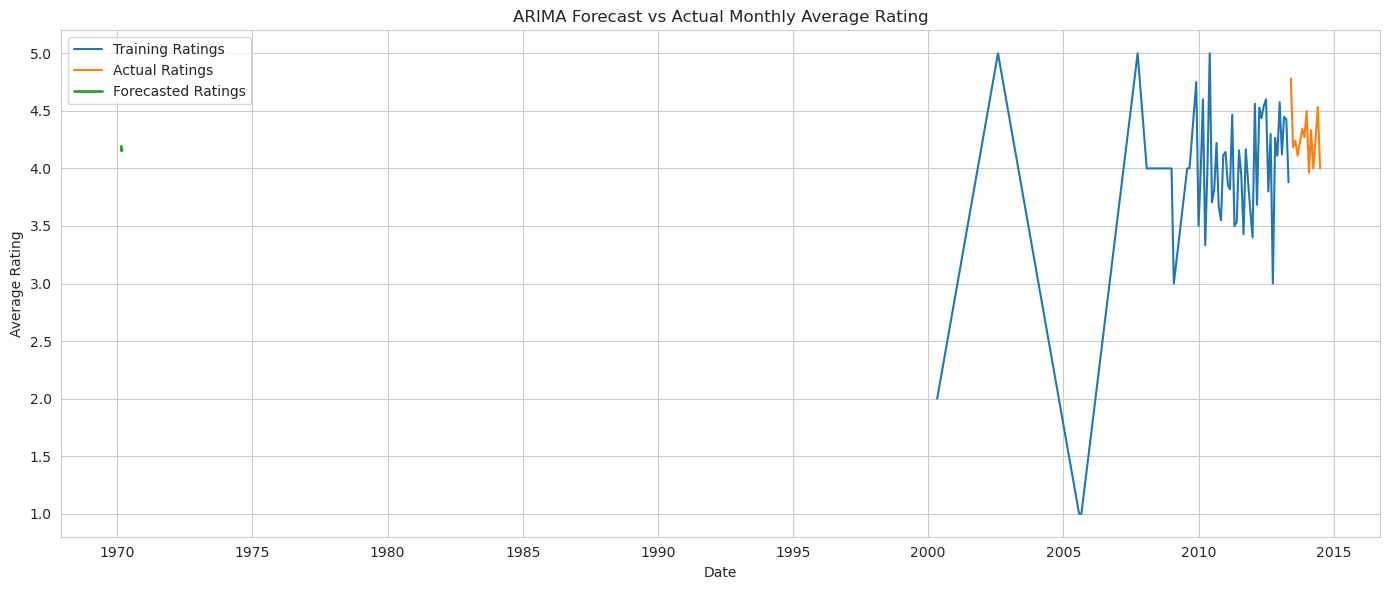

In [180]:
best_model = ARIMA(
    train,
    order=(1,1,1)
).fit()

forecast = best_model.forecast(
    steps=len(test)
)

plt.figure(figsize=(14, 6))

plt.plot(
    train,
    label="Training Ratings"
)

plt.plot(
    test,
    label="Actual Ratings"
)

plt.plot(
    forecast,
    label="Forecasted Ratings",
    linewidth=2
)

plt.title("ARIMA Forecast vs Actual Monthly Average Rating")
plt.xlabel("Date")
plt.ylabel("Average Rating")

plt.legend()

plt.tight_layout()
plt.show()

Residual diagnostics

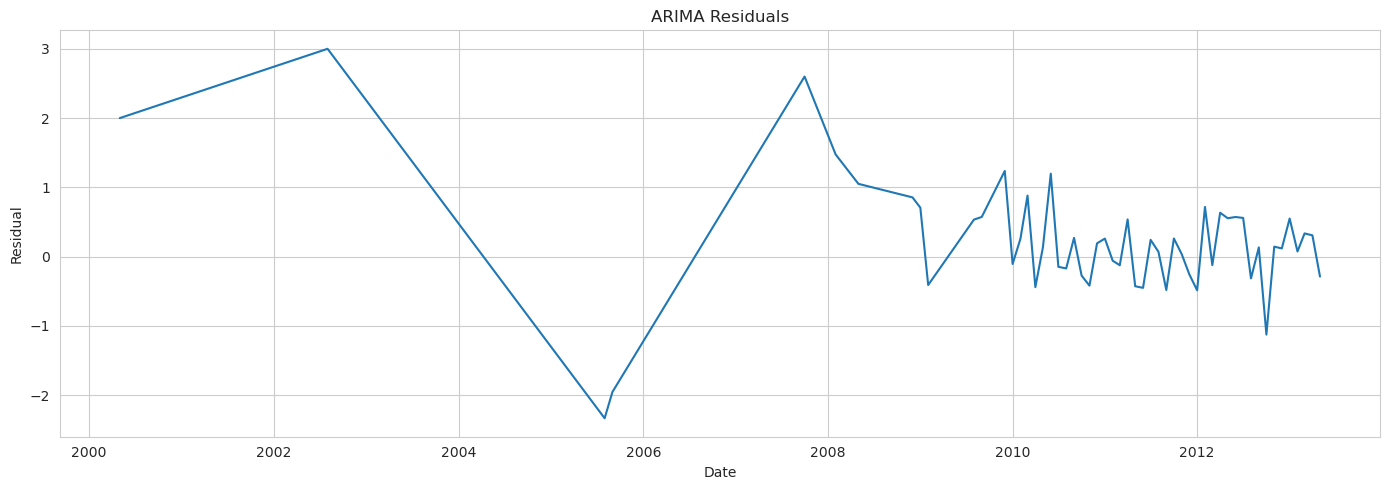

In [181]:
residuals = best_model.resid

plt.figure(figsize=(14, 5))

plt.plot(residuals)

plt.title("ARIMA Residuals")
plt.xlabel("Date")
plt.ylabel("Residual")

plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

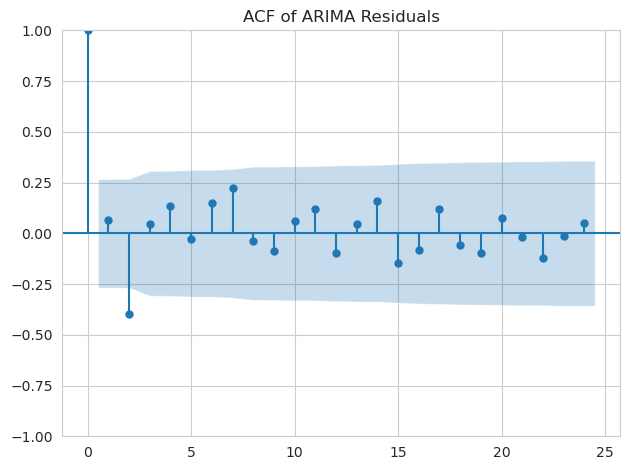

In [183]:
#check autocorrelation

plt.figure(figsize=(12, 5))

plot_acf(
    residuals.dropna(),
    lags=24
)

plt.title("ACF of ARIMA Residuals")

plt.tight_layout()
plt.show()

In [184]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(
    residuals.dropna(),
    lags=[6, 12],
    return_df=True
)

print(ljung_box)

      lb_stat  lb_pvalue
6   12.164803   0.058392
12  17.889740   0.119080


Reflection prompt:

I turned the review dates into real date format, then grouped the reviews by month. For each month I counted two things; how many reviews were posted and what the average star rating was.

The dataset covers about 14 years (2000 to 2014), but the early years are very quiet, sometimes zero reviews, 1 or 2 reviews a month. Then around late 2009 to early 2011, review activity suddenly exploded.This may be due to new product comming out and a product been promoted. 

The monthly average rating series is not stationary and The monthly average rating series is not stationary.After applying differencial its became stationary.

## Part 3: Neural Networks

In this section, you will transform text reviews into numerical features, train a neural network to predict ratings, and evaluate model performance.


Import the libraries

In [127]:
# Train/test split + encoding
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

# Text vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

# Model building / evaluation
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report, confusion_matrix

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [128]:
df = pd.read_csv("amazon_reviews_lab.csv")
df.head()

,product_id,rating,review_text,review_summary,review_time_raw,unix_review_time,timestamp,sentiment_label,review_length_words
0,6301977173,2,This film is definitely not for anyone who is ...,The best of Mark Twain's work - left out!,"05 12, 2000",9.580896e+08,2000-05-12,negative,302
1,6301977173,5,This movie was playing at Radio City Music Hal...,The best Tom Sawyer i ever saw.,"08 26, 2002",1.030320e+09,2002-08-26,positive,168
2,6301977173,1,I would love to buy this movie as I have been ...,Why no Widescreen?,"08 6, 2005",1.123286e+09,2005-08-06,negative,60
3,6301977173,1,The advertisment for this DVD on Amazon was in...,False advertising on this DVD,"09 11, 2005",1.126397e+09,2005-09-11,negative,104
4,9575871979,5,I bought some of these to try with a light usi...,Work GREAT!!,"10 15, 2007",1.192406e+09,2007-10-15,positive,60


In [129]:
print(df.shape)
print(df["rating"].value_counts().sort_index())

(997, 9)
rating
1     87
2     48
3     94
4    188
5    580
Name: count, dtype: int64


In [130]:
df = df.dropna(subset=["review_text", "rating"]).copy()

Define X and y

In [131]:
X = df["review_text"].astype(str)
y = df["rating"].astype(int)

In [132]:
print(X.head())
print(y.head())

0    This film is definitely not for anyone who is ...
1    This movie was playing at Radio City Music Hal...
2    I would love to buy this movie as I have been ...
3    The advertisment for this DVD on Amazon was in...
4    I bought some of these to try with a light usi...
Name: review_text, dtype: object
0    2
1    5
2    1
3    1
4    5
Name: rating, dtype: int64


Convert ratings from 1–5 to 0–4 since keras only wants labels from 0 to n

In [133]:
y = y-1
num_classes = 5  

Train and test split

In [134]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,      # Use stratify=y to preserve class balance. 
)

Vectorize the text using TF-IDF

In [135]:
vectorizer = TfidfVectorizer(
    max_features= 10_000, # keep at most 5000 features.
    ngram_range= (1,2),
    min_df= 2,
    max_df= 0.9,
    sublinear_tf= True,
    strip_accents="unicode",
    lowercase= True,
    stop_words="english"
)

# avoiding data leakage
X_train_tfidf = vectorizer.fit_transform(X_train)  
X_test_tfidf  = vectorizer.transform(X_test)      


TF-IDF shapes

In [136]:
print("Train TF-IDF:", X_train_tfidf.shape)
print("Test  TF-IDF:", X_test_tfidf.shape)

Train TF-IDF: (797, 7357)
Test  TF-IDF: (200, 7357)


797 training reviews

200 testing reviews

4,312 TF-IDF features

Converting sparse TF-IDF to dense.This is important because you're going to feed the data into a Keras neural network.

In [137]:
X_train_dense = X_train_tfidf.toarray().astype('float32')
X_test_dense  = X_test_tfidf.toarray().astype('float32')

print("Train dense:", X_train_dense.shape)
print("Test  dense:", X_test_dense.shape)


Train dense: (797, 7357)
Test  dense: (200, 7357)


One-hot encoding your ratings

In [138]:
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat  = to_categorical(y_test,  num_classes=num_classes)

print("y_train_cat:", y_train_cat.shape)   # (N_train, 5)
print("y_test_cat: ", y_test_cat.shape)    # (N_test,  5)

y_train_cat: (797, 5)
y_test_cat:  (200, 5)


Build a neural network model.

In [139]:
input_dim = X_train_dense.shape[1]   # 10_000 (or fewer if vocab < max_features)

model = models.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation="softmax"),
])

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 128)            │       941,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 950,405 (3.63 MB)

 Trainable params: 950,405 (3.63 MB)

 Non-trainable params: 0 (0.00 B)

The architecture: 

An input layer sized to the number of TF-IDF features

Two hidden layers with dropout

A softmax output with 5 units (one per rating class).

In [140]:
print(model.input_shape)
print(model.output_shape)   

(None, 7357)
(None, 5)


Compile the model.

In [141]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=['accuracy'],
)

We used Adam since it adapts the learning rate per parameter, so its reliably without much tuning.

categorical_crossen because the target is one-hot encoded

Train the model and store the training history.

In [142]:
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

history = model.fit(
    X_train_dense, y_train_cat,
    validation_split=0.15,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.5391 - loss: 1.5387 - val_accuracy: 0.5750 - val_loss: 1.4100
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5835 - loss: 1.2784 - val_accuracy: 0.5750 - val_loss: 1.2197
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5835 - loss: 1.0962 - val_accuracy: 0.5750 - val_loss: 1.1760
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5835 - loss: 0.9564 - val_accuracy: 0.5750 - val_loss: 1.1475
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5908 - loss: 0.8280 - val_accuracy: 0.5667 - val_loss: 1.1315
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6987 - loss: 0.6903 - val_accuracy: 0.5833 - val_loss: 1.1451
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8479 - loss: 0.5291 - val_accuracy: 0.5583 - val_loss: 1.1643
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9084 - loss: 0.3993 - val_accuracy: 0.5250 - v

Evaluate the model on the test set.

In [143]:
test_loss, test_acc = model.evaluate(X_test_dense, y_test_cat, verbose=0)

print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Test loss:     1.1401
Test accuracy: 0.5750


Our model correctly predicted the rating for about 58% of the test reviews.This could mean our ratings are heavily imbalanced toward 5-star reviews.

The test loss of 1.1354 indicates that the model's predicted class probabilities still contain considerable error.

Training history

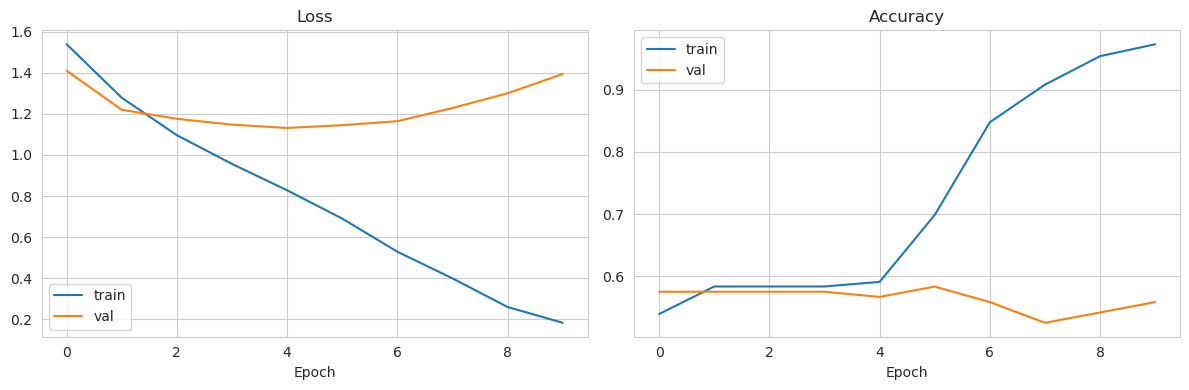

In [144]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

Generate predictions on the test set.

In [145]:
y_pred_probs = model.predict(X_test_dense, verbose=0)


y_pred = np.argmax(y_pred_probs, axis=1)

print("y_pred_probs shape:", y_pred_probs.shape)
print("y_pred shape:      ", y_pred.shape)
print("First 5 probability rows:\n", y_pred_probs[:5])
print("First 5 predictions:      ", y_pred[:5])
print("First 5 actual labels:    ", y_test.values[:5])

y_pred_probs shape: (200, 5)
y_pred shape:       (200,)
First 5 probability rows:
 [[0.0436968  0.02462148 0.0491941  0.14643721 0.73605037]
 [0.05278742 0.03718714 0.05303808 0.17621781 0.68076956]
 [0.0505162  0.02887591 0.05340835 0.1554494  0.71175003]
 [0.01450444 0.00939996 0.01731244 0.13290043 0.82588273]
 [0.02433232 0.0135837  0.02733925 0.11235674 0.82238793]]
First 5 predictions:       [4 4 4 4 4]
First 5 actual labels:     [4 0 3 3 4]


Classification report and/or confusion matrix to assess performance.

In [146]:
print(classification_report(
    y_test, y_pred,
    labels=[0, 1, 2, 3, 4],
    target_names=["1 star", "2 star", "3 star", "4 star", "5 star"],
    digits=3,
    zero_division=0,
))

              precision    recall  f1-score   support

      1 star      0.000     0.000     0.000        17
      2 star      0.000     0.000     0.000        10
      3 star      0.000     0.000     0.000        19
      4 star      0.000     0.000     0.000        38
      5 star      0.584     0.991     0.735       116

    accuracy                          0.575       200
   macro avg      0.117     0.198     0.147       200
weighted avg      0.339     0.575     0.426       200



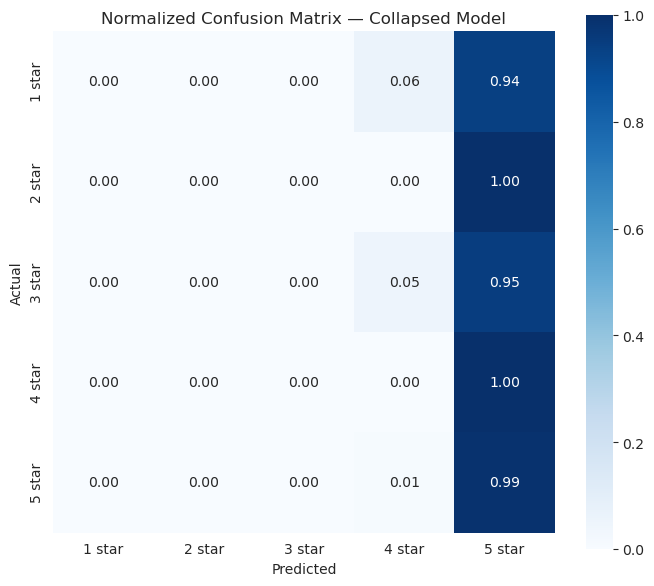

In [152]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2, 3, 4])

# Row-normalize safely (avoid division by zero if any class has zero support)
row_sums = cm.sum(axis=1, keepdims=True).astype(float)
cm_norm = np.divide(cm.astype(float), row_sums, where=row_sums != 0)
cm_norm = np.nan_to_num(cm_norm)   # zeros out any NaN from zero-support rows

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_norm,
    annot=True, fmt='.2f', cmap='Blues',
    xticklabels=["1 star", "2 star", "3 star", "4 star", "5 star"],
    yticklabels=["1 star", "2 star", "3 star", "4 star", "5 star"],
    vmin=0, vmax=1, square=True,
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Normalized Confusion Matrix — Collapsed Model')
plt.tight_layout()
plt.show()


Confusion Matrix

In [153]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2, 3, 4])

print("y_test counts:", np.bincount(y_test, minlength=5))
print("y_pred counts:", np.bincount(y_pred, minlength=5))
print("cm row sums:", cm.sum(axis=1))   # must equal y_test counts

y_test counts: [ 17  10  19  38 116]
y_pred counts: [  0   0   0   3 197]
cm row sums: [ 17  10  19  38 116]


In [148]:
print("y_test counts:", np.bincount(y_test, minlength=5))

y_test counts: [ 17  10  19  38 116]


Reflection prompt

The model is strongly biased toward predicting 5 stars. This explains the relatively low F1 score (0.147) despite the model achieving 57.5% accuracy. The accuracy is largely driven by the model's performance on the dominant 5-star class, while its ability to distinguish the lower rating classes is poor.This is a class imbalance problem.The solution is to use use class weights when training `class_weight="balanced"`
